In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import pandas as pd

# Ensure the notebook can find the /src directory
root_path = Path.cwd().parent
if str(root_path) not in sys.path:
    sys.path.append(str(root_path))

In [2]:
from src.data_loader import VesselDataLoader
from src.visualizer import plot_block_space, plot_mode_statistics, plot_series
from src.data_processing import engineer_telemetry_features
from src.mission_profiler import MissionProfiler, ScenarioEvaluator

Processing Rotherhithe_voy_179.csv...


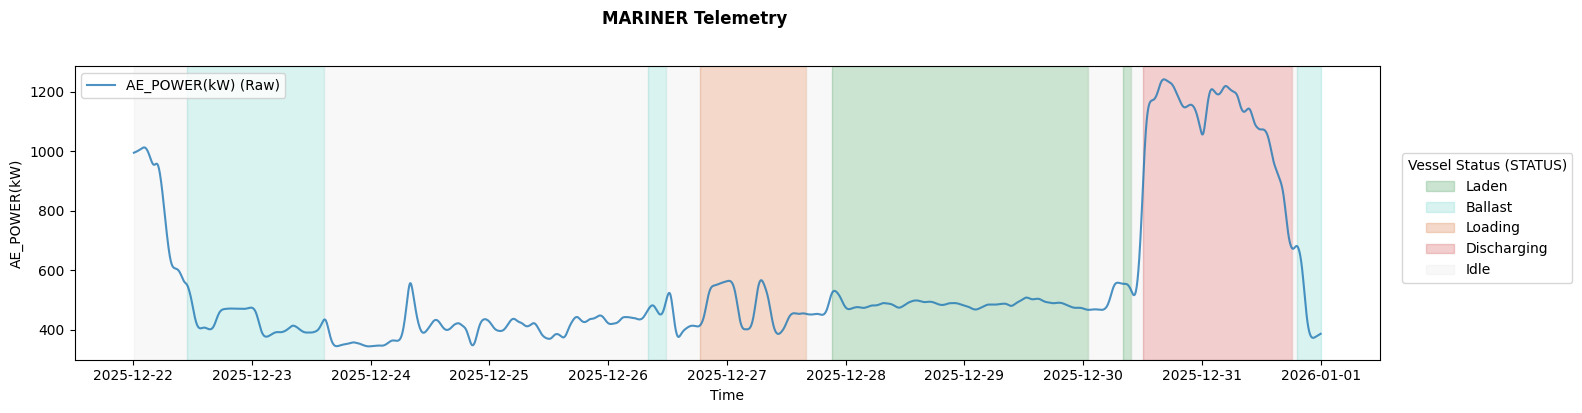

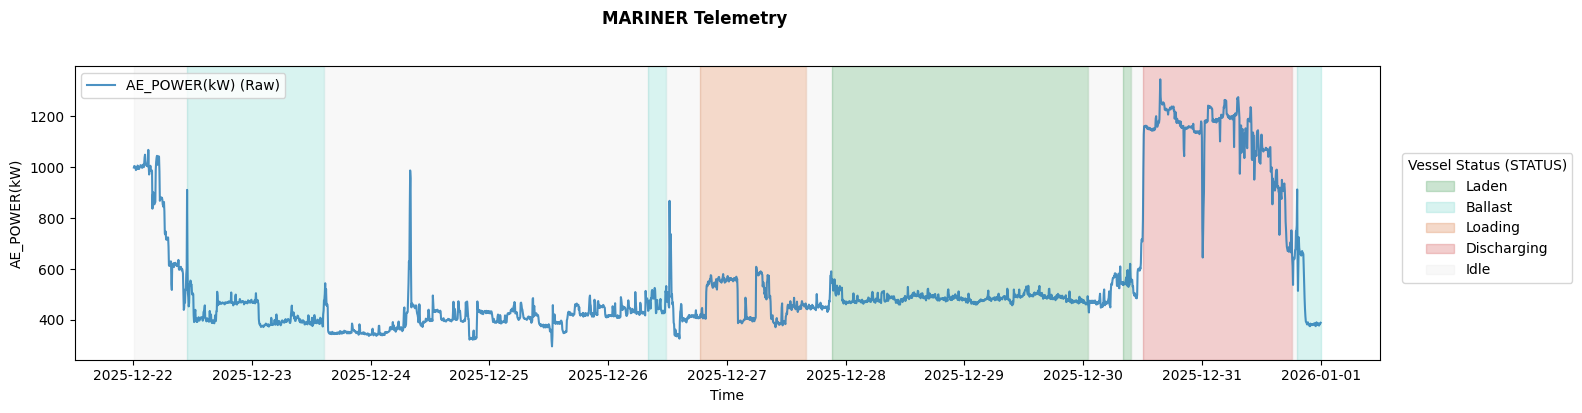

In [3]:
filenames = ["Rotherhithe_voy_179.csv"]
raw_registry_entries = []
filtered_registry_entries = []

profiler = MissionProfiler(speed_threshold=1.0)

for filename in filenames:
    print(f"Processing {filename}...")
    
    # 1. Load and process
    raw_data_file = root_path / "data" / "raw" / filename
    loader = VesselDataLoader(raw_data_file)
    raw_df = loader.load_and_clean()
    filtered_df = engineer_telemetry_features(raw_df, filter_method='butter')
    raw_df = engineer_telemetry_features(raw_df, filter_method='raw')
    
    # 2. Generate Registries
    filtered_registry_df = profiler.generate_block_registry(
        filtered_df, 
        source_file_name=filename, 
        merge_loitering=False, 
        unify_port_ops=False
    )
    raw_registry_df = profiler.generate_block_registry(
        raw_df, 
        source_file_name=filename, 
        merge_loitering=False, 
        unify_port_ops=False
    )
    filtered_registry_entries.append(filtered_registry_df)
    raw_registry_entries.append(raw_registry_df)
    plot_series(filtered_df, ['AE_POWER(kW)'])
    plot_series(raw_df, ['AE_POWER(kW)'])

# 3. Concatenate all blocks and generate mathematically consistent global stats
combined_filtered_registry = pd.concat(filtered_registry_entries, ignore_index=True)
combined_filtered_stats = profiler.extract_global_statistics(combined_filtered_registry)

combined_raw_registry = pd.concat(raw_registry_entries, ignore_index=True)
combined_raw_stats = profiler.extract_global_statistics(combined_raw_registry)


In [4]:
fig_bricks_fatigue = plot_block_space(combined_filtered_registry, y_axis_metric='Relative_Fatigue_Activity_Rate', print_table=True)
fig_bricks_fatigue.show()

fig_stats_fatigue = plot_mode_statistics(combined_filtered_stats, y_axis_metric='Relative_Fatigue_Activity_Rate', print_table=True)
fig_stats_fatigue.show()


--- Physical Block Registry Summary ---
                  MODE  Duration_h  Mean_Power_kW  H2_Rate_Lower_kg_h  H2_Rate_Upper_kg_h  Relative_Fatigue_Activity_Rate
0        Sea_Loitering   65.500000     405.032578           22.101527           27.012977                        0.024869
1  Sea_Transit_Ballast   31.416667     432.256012           23.587035           28.828599                        0.023149
2            Port_Idle   12.000000     441.021898           24.065366           29.413225                        0.044173
3         Port_Loading   21.416667     477.993670           26.082815           31.878996                        0.066515
4        Sea_Loitering    7.083333     498.723808           27.214002           33.261558                        0.014732
5    Sea_Transit_Laden   53.333333     489.006894           26.683777           32.613505                        0.004113
6            Port_Idle    2.500000     600.052970           32.743259           40.019539                


--- Operational State Statistics Summary ---
               MODE  Mean_Power_kW  Mean_H2_Rate_Lower_kg_h  Mean_H2_Rate_Upper_kg_h  Mean_Power_Fluctuation_Intensity  Relative_Fatigue_Activity_Rate  Number_of_Blocks  Total_Logged_Hours  Time_Fraction
          Port_Idle     468.441049                25.561555                31.241900                          2.138593                        0.134754                 2           14.500000       0.064901
       Port_Loading     477.993670                26.082815                31.878996                          0.635384                        0.066515                 1           21.416667       0.095860
     Port_Unloading    1111.690569                60.661932                74.142362                          1.411437                        0.208026                 1           30.166667       0.135024
      Sea_Loitering     414.175809                22.600448                27.622770                          0.224931                    

In [5]:
fig_bricks_fatigue = plot_block_space(combined_raw_registry, y_axis_metric='Relative_Fatigue_Activity_Rate', print_table=True)
fig_bricks_fatigue.show()

fig_stats_fatigue = plot_mode_statistics(combined_raw_stats, y_axis_metric='Relative_Fatigue_Activity_Rate', print_table=True)
fig_stats_fatigue.show()


--- Physical Block Registry Summary ---
                  MODE  Duration_h  Mean_Power_kW  H2_Rate_Lower_kg_h  H2_Rate_Upper_kg_h  Relative_Fatigue_Activity_Rate
0        Sea_Loitering   65.500000     405.357422           22.119253           27.034642                        0.258413
1  Sea_Transit_Ballast   31.416667     431.844409           23.564575           28.801148                        0.223487
2            Port_Idle   12.000000     442.411545           24.141195           29.505905                        0.664373
3         Port_Loading   21.416667     477.901841           26.077804           31.872872                        0.160575
4        Sea_Loitering    7.083333     498.879159           27.222479           33.271919                        0.135913
5    Sea_Transit_Laden   53.333333     489.237148           26.696341           32.628861                        0.040246
6            Port_Idle    3.500000     596.540012           32.551567           39.785248                


--- Operational State Statistics Summary ---
               MODE  Mean_Power_kW  Mean_H2_Rate_Lower_kg_h  Mean_H2_Rate_Upper_kg_h  Mean_Power_Fluctuation_Intensity  Relative_Fatigue_Activity_Rate  Number_of_Blocks  Total_Logged_Hours  Time_Fraction
          Port_Idle     477.214747                26.040311                31.827047                         79.725946                        0.638926                 2           15.500000       0.069068
       Port_Loading     477.901841                26.077804                31.872872                         21.428734                        0.160575                 1           21.416667       0.095433
     Port_Unloading    1113.980923                60.786911                74.295113                         79.375652                        0.915906                 1           30.166667       0.134423
      Sea_Loitering     414.484113                22.617271                27.643332                         23.135801                    

In [6]:
evaluator_raw=ScenarioEvaluator(combined_raw_stats)
evaluator_filtered=ScenarioEvaluator(combined_filtered_stats)

scenario = {
    'Port_Idle': 1000*0.14,
    'Port_Loading': 1000*0.06,
    'Port_Unloading': 1000*0.14,
    'Sea_Loitering': 1000*0.19,
    'Sea_Transit_Ballast': 1000*0.12,
    'Sea_Transit_Laden': 1000*0.35
}

results_raw = evaluator_raw.evaluate(scenario, print_results=True)
results_filtered = evaluator_filtered.evaluate(scenario, print_results=True)


SCENARIO EVALUATION REPORT
Total Duration    : 1000.0 h
Energy Demanded   : 553247.8 kWh
---------------------------------------------
H2 Consumption    : [30189.23 - 36897.95] kg
Fatigue Index     : 315.0427 units
Fluctuation Index : 33447.39 kW²/s²


SCENARIO EVALUATION REPORT
Total Duration    : 1000.0 h
Energy Demanded   : 551614.6 kWh
---------------------------------------------
H2 Consumption    : [30100.11 - 36789.02] kg
Fatigue Index     : 60.7349 units
Fluctuation Index : 607.56 kW²/s²



In [7]:
scenario_no_unloading = {
    'Port_Idle': 1000*(0.14+0.06+0.14),  # Combine Idle, Loading, and Unloading into a single "Port" category
    'Sea_Loitering': 1000*0.19,
    'Sea_Transit_Ballast': 1000*0.12,
    'Sea_Transit_Laden': 1000*0.35
}

results_no_unloading_raw = evaluator_raw.evaluate(scenario_no_unloading, print_results=True)
results_no_unloading_filtered = evaluator_filtered.evaluate(scenario_no_unloading, print_results=True)


SCENARIO EVALUATION REPORT
Total Duration    : 1000.0 h
Energy Demanded   : 464059.3 kWh
---------------------------------------------
H2 Consumption    : [25322.46 - 30949.67] kg
Fatigue Index     : 304.9664 units
Fluctuation Index : 36994.26 kW²/s²


SCENARIO EVALUATION REPORT
Total Duration    : 1000.0 h
Energy Demanded   : 460986.5 kWh
---------------------------------------------
H2 Consumption    : [25154.78 - 30744.73] kg
Fatigue Index     : 54.5710 units
Fluctuation Index : 799.56 kW²/s²

